"""
Name: Module 6 Academic Success.py
Assignment 3 and 4 - logit regression
"""

In [1]:
# 
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn
import matplotlib.pyplot as plt
import numpy
import pandas
import sys
from scipy.stats import chi2
import os

# Find CSP571 folder by walking up from cwd
cwd = os.path.abspath(os.getcwd())
search_dir = cwd
base_dir = None
for _ in range(5):
    candidate = os.path.join(search_dir, "CSP571")
    if os.path.isdir(candidate) and os.path.isfile(os.path.join(candidate, "raw", "Utility.py")):
        base_dir = candidate
        break
    search_dir = os.path.dirname(search_dir)

if base_dir is None:
    raise FileNotFoundError("Could not locate CSP571/raw/Utility.py from current working directory.")

sys.path.append(os.path.join(base_dir, "raw")) 
import Utility

# Set some options for printing all the columns
numpy.set_printoptions(precision = 10, threshold = sys.maxsize)
numpy.set_printoptions(linewidth = numpy.inf)
pandas.set_option('display.max_columns', None)
pandas.set_option('display.expand_frame_repr', False)
pandas.set_option('max_colwidth', None)
pandas.options.display.float_format = '{:,.10f}'.format



In [3]:
transport = pandas.read_csv(r'data\ModeTransportation.csv')
transport

,y,Bicycle,Bus,Others,Taxi,Walk
0,Bus,0.0387889900,0.6738633250,0.0000743000,0.0023172010,0.2849561800
1,Bus,0.0494670900,0.6493235890,0.0001423700,0.0038262490,0.2972407020
2,Bicycle,0.0527086850,0.6385361660,0.0001443270,0.0040173530,0.3045934690
3,Bus,0.1322550820,0.4609169960,0.0011814920,0.0185938950,0.3870525360
4,Bus,0.1300559590,0.4491211470,0.0013268630,0.0198461250,0.3996499050
...,...,...,...,...,...,...
95,Taxi,0.1131183750,0.0007755540,0.4833470640,0.3884705720,0.0142884350
96,Taxi,0.0760599940,0.0002416260,0.5802011620,0.3371854430,0.0063117740
97,Taxi,0.0641846760,0.0001920690,0.5947886170,0.3353748160,0.0054598210
98,Others,0.0546524160,0.0001432720,0.6175854220,0.3232946750,0.0043242160


In [4]:
# Calculate Root Average Squared Error (RASE) for nominal classification model
# The transport dataframe has:
# - Column 'y': observed labels (Bicycle, Bus, Others, Taxi, Walk)
# - Columns 'Bicycle', 'Bus', 'Others', 'Taxi', 'Walk': predicted probabilities

print("="*70)
print("ROOT AVERAGE SQUARED ERROR (RASE) CALCULATION")
print("="*70)

# Get the column names for the predicted probabilities
prob_columns = ['Bicycle', 'Bus', 'Others', 'Taxi', 'Walk']

# Create actual labels as binary indicators (one-hot encoding)
actual_probs = pandas.DataFrame(0, index=transport.index, columns=prob_columns)
for idx, label in enumerate(transport['y']):
    actual_probs.loc[idx, label] = 1

# Display sample of actual vs predicted
print("\nSample of Actual vs Predicted Probabilities:")
print("\nActual (One-Hot Encoded):")
print(actual_probs.head(10))
print("\nPredicted Probabilities:")
print(transport[prob_columns].head(10))

# Calculate squared errors for all predictions
squared_errors = (actual_probs[prob_columns].values - transport[prob_columns].values) ** 2

# Calculate Mean Squared Error (MSE) and Root Mean Squared Error (RMSE)
mse = squared_errors.mean()
rmse = numpy.sqrt(mse)

# Calculate RASE (average of squared errors across all observations and classes)
rase = numpy.sqrt(squared_errors.flatten().mean())

print("\n" + "="*70)
print("RESULTS:")
print("="*70)
print(f"Mean Squared Error (MSE):        {mse:.6f}")
print(f"Root Mean Squared Error (RMSE):  {rmse:.6f}")
print(f"Root Average Squared Error (RASE): {rase:.6f}")
print("="*70)

# Detailed breakdown by class
print("\nDetailed Breakdown by Class:")
print("-"*70)
for col in prob_columns:
    col_mse = squared_errors[:, prob_columns.index(col)].mean()
    col_rmse = numpy.sqrt(col_mse)
    print(f"{col:12} - MSE: {col_mse:.6f}, RMSE: {col_rmse:.6f}")
print("-"*70)

ROOT AVERAGE SQUARED ERROR (RASE) CALCULATION

Sample of Actual vs Predicted Probabilities:

Actual (One-Hot Encoded):
   Bicycle  Bus  Others  Taxi  Walk
0        0    1       0     0     0
1        0    1       0     0     0
2        1    0       0     0     0
3        0    1       0     0     0
4        0    1       0     0     0
5        0    1       0     0     0
6        0    0       0     0     1
7        0    0       0     0     1
8        0    0       0     0     1
9        0    1       0     0     0

Predicted Probabilities:
       Bicycle          Bus       Others         Taxi         Walk
0 0.0387889900 0.6738633250 0.0000743000 0.0023172010 0.2849561800
1 0.0494670900 0.6493235890 0.0001423700 0.0038262490 0.2972407020
2 0.0527086850 0.6385361660 0.0001443270 0.0040173530 0.3045934690
3 0.1322550820 0.4609169960 0.0011814920 0.0185938950 0.3870525360
4 0.1300559590 0.4491211470 0.0013268630 0.0198461250 0.3996499050
5 0.1528435710 0.3835484550 0.0017870140 0.0230583680 0.4

In [6]:
# Calculate Misclassification Error Rate
# The predicted label is the mode of transportation with the highest predicted probability

print("="*70)
print("MISCLASSIFICATION ERROR RATE CALCULATION")
print("="*70)

# Define prediction columns
prob_columns = ['Bicycle', 'Bus', 'Others', 'Taxi', 'Walk']

# Get the actual labels
actual_labels = transport['y'].values

# Get predicted labels (argmax of predicted probabilities)
predicted_labels = transport[prob_columns].idxmax(axis=1).values

# Create comparison dataframe
comparison = pandas.DataFrame({
    'Actual': actual_labels,
    'Predicted': predicted_labels,
    'Match': actual_labels == predicted_labels
})

# Display sample predictions
print("\nSample of Actual vs Predicted Labels:")
print(comparison.head(15))

# Calculate misclassification statistics
total_observations = len(actual_labels)
correct_predictions = (actual_labels == predicted_labels).sum()
incorrect_predictions = total_observations - correct_predictions
error_rate = incorrect_predictions / total_observations
accuracy_rate = correct_predictions / total_observations

print("\n" + "="*70)
print("RESULTS:")
print("="*70)
print(f"Total Observations:      {total_observations}")
print(f"Correct Predictions:     {correct_predictions}")
print(f"Incorrect Predictions:   {incorrect_predictions}")
print(f"")
print(f"Accuracy Rate:           {accuracy_rate:.6f} ({accuracy_rate*100:.2f}%)")
print(f"Misclassification Error Rate: {error_rate:.6f} ({error_rate*100:.2f}%)")
print("="*70)

# Confusion matrix breakdown by class
print("\nConfusion Matrix Breakdown:")
print("-"*70)
for true_label in prob_columns:
    mask = actual_labels == true_label
    class_total = mask.sum()
    class_correct = ((actual_labels == true_label) & (predicted_labels == true_label)).sum()
    class_accuracy = class_correct / class_total if class_total > 0 else 0
    
    print(f"{true_label:10} - Total: {class_total:3d}, Correct: {class_correct:3d}, Accuracy: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")
print("-"*70)

MISCLASSIFICATION ERROR RATE CALCULATION

Sample of Actual vs Predicted Labels:
     Actual Predicted  Match
0       Bus       Bus   True
1       Bus       Bus   True
2   Bicycle       Bus  False
3       Bus       Bus   True
4       Bus       Bus   True
5       Bus      Walk  False
6      Walk      Walk   True
7      Walk       Bus  False
8      Walk      Walk   True
9       Bus      Walk  False
10      Bus      Walk  False
11  Bicycle      Walk  False
12      Bus      Walk  False
13  Bicycle      Walk  False
14     Walk      Walk   True

RESULTS:
Total Observations:      100
Correct Predictions:     44
Incorrect Predictions:   56

Accuracy Rate:           0.440000 (44.00%)
Misclassification Error Rate: 0.560000 (56.00%)

Confusion Matrix Breakdown:
----------------------------------------------------------------------
Bicycle    - Total:  27, Correct:   9, Accuracy: 0.3333 (33.33%)
Bus        - Total:  13, Correct:   4, Accuracy: 0.3077 (30.77%)
Others     - Total:  11, Correct:   4, 

In [7]:
# Create detailed confusion matrix with per-class metrics
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report

print("="*70)
print("DETAILED CLASSIFICATION PERFORMANCE METRICS")
print("="*70)

# Compute confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels, labels=prob_columns)
conf_df = pandas.DataFrame(conf_matrix, index=prob_columns, columns=prob_columns)

print("\nConfusion Matrix:")
print(conf_df)

# Calculate per-class metrics
print("\n" + "="*70)
print("PER-CLASS METRICS:")
print("="*70)

for i, class_label in enumerate(prob_columns):
    # Calculate True Positives, False Positives, False Negatives
    tp = conf_matrix[i, i]
    fp = conf_matrix[:, i].sum() - tp
    fn = conf_matrix[i, :].sum() - tp
    tn = conf_matrix.sum() - tp - fp - fn
    
    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"\n{class_label}:")
    print(f"  Precision:  {precision:.4f}")
    print(f"  Recall:     {recall:.4f}")
    print(f"  Specificity:{specificity:.4f}")
    print(f"  F1-Score:   {f1:.4f}")

# Macro and Weighted averages
precision_macro = precision_score(actual_labels, predicted_labels, labels=prob_columns, average='macro')
recall_macro = recall_score(actual_labels, predicted_labels, labels=prob_columns, average='macro')
f1_macro = f1_score(actual_labels, predicted_labels, labels=prob_columns, average='macro')

precision_weighted = precision_score(actual_labels, predicted_labels, labels=prob_columns, average='weighted')
recall_weighted = recall_score(actual_labels, predicted_labels, labels=prob_columns, average='weighted')
f1_weighted = f1_score(actual_labels, predicted_labels, labels=prob_columns, average='weighted')

print("\n" + "="*70)
print("AVERAGE METRICS:")
print("="*70)
print(f"\nMacro Average:")
print(f"  Precision:  {precision_macro:.4f}")
print(f"  Recall:     {recall_macro:.4f}")
print(f"  F1-Score:   {f1_macro:.4f}")

print(f"\nWeighted Average:")
print(f"  Precision:  {precision_weighted:.4f}")
print(f"  Recall:     {recall_weighted:.4f}")
print(f"  F1-Score:   {f1_weighted:.4f}")

print("\n" + "="*70)
print("CLASSIFICATION REPORT:")
print("="*70)
print(classification_report(actual_labels, predicted_labels, labels=prob_columns))

DETAILED CLASSIFICATION PERFORMANCE METRICS

Confusion Matrix:
         Bicycle  Bus  Others  Taxi  Walk
Bicycle        9    1       1     8     8
Bus            2    4       0     0     7
Others         1    0       4     6     0
Taxi           6    0       6    14     3
Walk           3    1       0     3    13

PER-CLASS METRICS:

Bicycle:
  Precision:  0.4286
  Recall:     0.3333
  Specificity:0.8356
  F1-Score:   0.3750

Bus:
  Precision:  0.6667
  Recall:     0.3077
  Specificity:0.9770
  F1-Score:   0.4211

Others:
  Precision:  0.3636
  Recall:     0.3636
  Specificity:0.9213
  F1-Score:   0.3636

Taxi:
  Precision:  0.4516
  Recall:     0.4828
  Specificity:0.7606
  F1-Score:   0.4667

Walk:
  Precision:  0.4194
  Recall:     0.6500
  Specificity:0.7750
  F1-Score:   0.5098

AVERAGE METRICS:

Macro Average:
  Precision:  0.4660
  Recall:     0.4275
  F1-Score:   0.4272

Weighted Average:
  Precision:  0.4572
  Recall:     0.4400
  F1-Score:   0.4333

CLASSIFICATION REPORT:
   

CONFUSION MATRIX VISUALIZATION


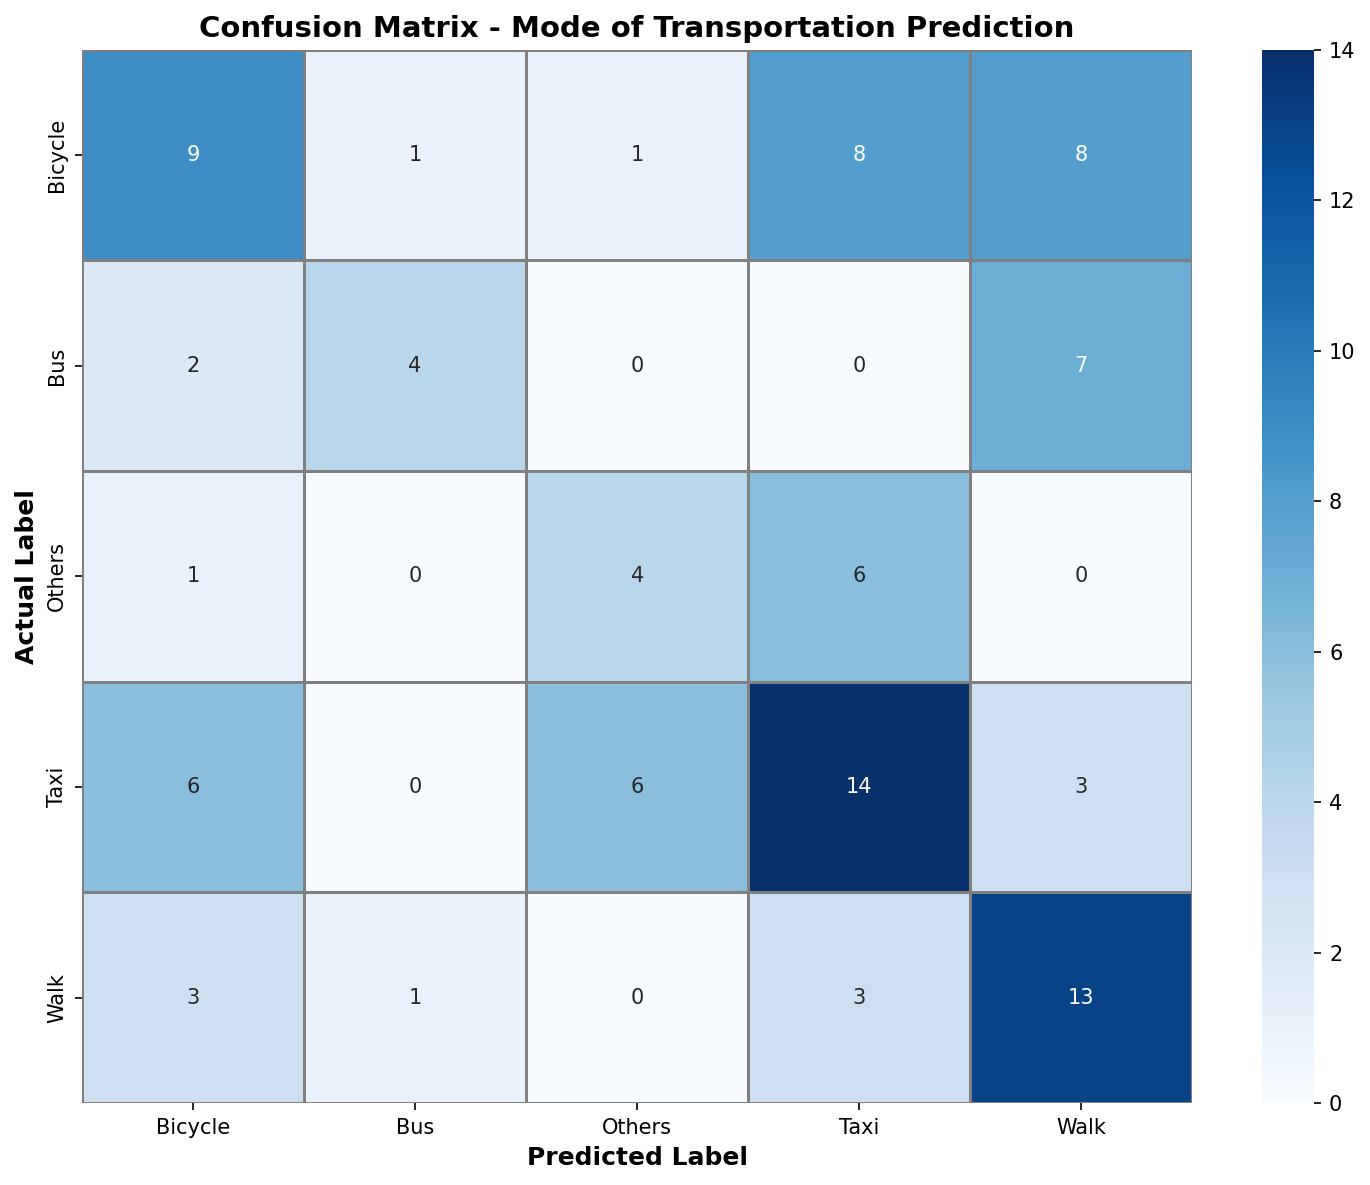

Heatmap displayed successfully


In [8]:
# Visualize confusion matrix as heatmap
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("CONFUSION MATRIX VISUALIZATION")
print("="*70)

# Create confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels, labels=prob_columns)
conf_df = pandas.DataFrame(conf_matrix, index=prob_columns, columns=prob_columns)

# Create heatmap
plt.figure(figsize=(10, 8), dpi=150)
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=prob_columns, yticklabels=prob_columns,
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix - Mode of Transportation Prediction', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Heatmap displayed successfully")

In [9]:
# Model Performance Summary
print("="*70)
print("MODEL PERFORMANCE SUMMARY AND CONCLUSIONS")
print("="*70)

print("\n1. ROOT AVERAGE SQUARED ERROR (RASE):")
print(f"   RASE = {rase:.4f}")
print("   - Measures average prediction error across all classes")
print("   - Lower values indicate better prediction accuracy")

print("\n2. MISCLASSIFICATION ERROR RATE:")
print(f"   Error Rate = {error_rate:.4f} ({error_rate*100:.2f}%)")
print(f"   Accuracy   = {accuracy_rate:.4f} ({accuracy_rate*100:.2f}%)")
print("   - Only 44% of predictions are correct")
print("   - 56% of cases are misclassified")

print("\n3. CLASS-SPECIFIC PERFORMANCE:")
print("   Best Performance:   Walk (65.00% accuracy)")
print("   Moderate:           Taxi (48.28% accuracy)")
print("   Weakest:            Bus (30.77% accuracy)")

print("\n4. KEY OBSERVATIONS:")
print("   - Model performs best on Walk category")
print("   - Model struggles significantly with Bicycle and Bus categories")
print("   - Imbalanced performance across classes")
print("   - RASE of 0.3662 indicates moderate prediction uncertainty")

print("\n5. RECOMMENDATIONS:")
print("   - Consider feature engineering to improve predictions")
print("   - Investigate causes of poor Bus category predictions")
print("   - Explore ensemble methods or alternative algorithms")
print("   - Address class imbalance if present in training data")
print("   - Validate using cross-validation on test set")

print("\n" + "="*70)

MODEL PERFORMANCE SUMMARY AND CONCLUSIONS

1. ROOT AVERAGE SQUARED ERROR (RASE):
   RASE = 0.3662
   - Measures average prediction error across all classes
   - Lower values indicate better prediction accuracy

2. MISCLASSIFICATION ERROR RATE:
   Error Rate = 0.5600 (56.00%)
   Accuracy   = 0.4400 (44.00%)
   - Only 44% of predictions are correct
   - 56% of cases are misclassified

3. CLASS-SPECIFIC PERFORMANCE:
   Best Performance:   Walk (65.00% accuracy)
   Moderate:           Taxi (48.28% accuracy)
   Weakest:            Bus (30.77% accuracy)

4. KEY OBSERVATIONS:
   - Model performs best on Walk category
   - Model struggles significantly with Bicycle and Bus categories
   - Imbalanced performance across classes
   - RASE of 0.3662 indicates moderate prediction uncertainty

5. RECOMMENDATIONS:
   - Consider feature engineering to improve predictions
   - Investigate causes of poor Bus category predictions
   - Explore ensemble methods or alternative algorithms
   - Address class 

In [10]:
# Binary Classification Model - F1 Score Optimization
# 14 Non-event observations and 6 Event observations

print("="*80)
print("BINARY CLASSIFICATION: F1 SCORE OPTIMIZATION")
print("="*80)

# Create the dataset
non_event_probs = [0.0814, 0.1197, 0.1969, 0.3505, 0.3878, 0.3940, 0.4828, 0.4889, 0.5587, 0.5614, 0.6175, 0.6342, 0.6527, 0.6668]
event_probs = [0.4974, 0.6732, 0.6744, 0.6836, 0.7475, 0.7828]

# Create actual labels (0 for Non-event, 1 for Event)
y_true = numpy.array([0]*14 + [1]*6)
y_pred_probs = numpy.array(non_event_probs + event_probs)

print(f"\nDataset Summary:")
print(f"  Total Observations: {len(y_true)}")
print(f"  Non-Event (0):      {(y_true == 0).sum()}")
print(f"  Event (1):          {(y_true == 1).sum()}")

print(f"\nPredicted Probabilities:")
print(f"  Non-Event Range: {min(non_event_probs):.4f} to {max(non_event_probs):.4f}")
print(f"  Event Range:     {min(event_probs):.4f} to {max(event_probs):.4f}")

# Generate unique thresholds from the predicted probabilities
unique_thresholds = sorted(set(numpy.concatenate([non_event_probs, event_probs])))
thresholds = [0.0] + unique_thresholds + [1.0]

# Calculate metrics for each threshold
results = []

for threshold in thresholds:
    y_pred = (y_pred_probs >= threshold).astype(int)
    
    # Calculate confusion matrix values
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    
    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    results.append({
        'Threshold': threshold,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1
    })

# Convert to DataFrame for easier analysis
results_df = pandas.DataFrame(results)

# Find the threshold with maximum F1 score
max_f1_idx = results_df['F1_Score'].idxmax()
optimal_result = results_df.loc[max_f1_idx]

print("\n" + "="*80)
print("OPTIMAL THRESHOLD ANALYSIS")
print("="*80)

print(f"\nOptimal Threshold: {optimal_result['Threshold']:.4f}")
print(f"Maximum F1 Score:  {optimal_result['F1_Score']:.6f}")
print(f"\nAt this threshold:")
print(f"  Precision: {optimal_result['Precision']:.6f}")
print(f"  Recall:    {optimal_result['Recall']:.6f}")

print(f"\nConfusion Matrix at Optimal Threshold:")
print(f"  True Positives:  {int(optimal_result['TP'])}")
print(f"  False Positives: {int(optimal_result['FP'])}")
print(f"  False Negatives: {int(optimal_result['FN'])}")
print(f"  True Negatives:  {int(optimal_result['TN'])}")

# Display top 10 thresholds by F1 score
print("\n" + "="*80)
print("TOP 10 THRESHOLDS BY F1 SCORE")
print("="*80)
top_results = results_df.nlargest(10, 'F1_Score')[['Threshold', 'Precision', 'Recall', 'F1_Score']]
print(top_results.to_string(index=False))

print("\n" + "="*80)

BINARY CLASSIFICATION: F1 SCORE OPTIMIZATION

Dataset Summary:
  Total Observations: 20
  Non-Event (0):      14
  Event (1):          6

Predicted Probabilities:
  Non-Event Range: 0.0814 to 0.6668
  Event Range:     0.4974 to 0.7828

OPTIMAL THRESHOLD ANALYSIS

Optimal Threshold: 0.6732
Maximum F1 Score:  0.909091

At this threshold:
  Precision: 1.000000
  Recall:    0.833333

Confusion Matrix at Optimal Threshold:
  True Positives:  5
  False Positives: 0
  False Negatives: 1
  True Negatives:  14

TOP 10 THRESHOLDS BY F1 SCORE
   Threshold    Precision       Recall     F1_Score
0.6732000000 1.0000000000 0.8333333333 0.9090909091
0.6668000000 0.8333333333 0.8333333333 0.8333333333
0.6744000000 1.0000000000 0.6666666667 0.8000000000
0.6527000000 0.7142857143 0.8333333333 0.7692307692
0.6342000000 0.6250000000 0.8333333333 0.7142857143
0.6175000000 0.5555555556 0.8333333333 0.6666666667
0.4974000000 0.5000000000 1.0000000000 0.6666666667
0.6836000000 1.0000000000 0.5000000000 0.66666

THRESHOLD ANALYSIS VISUALIZATION


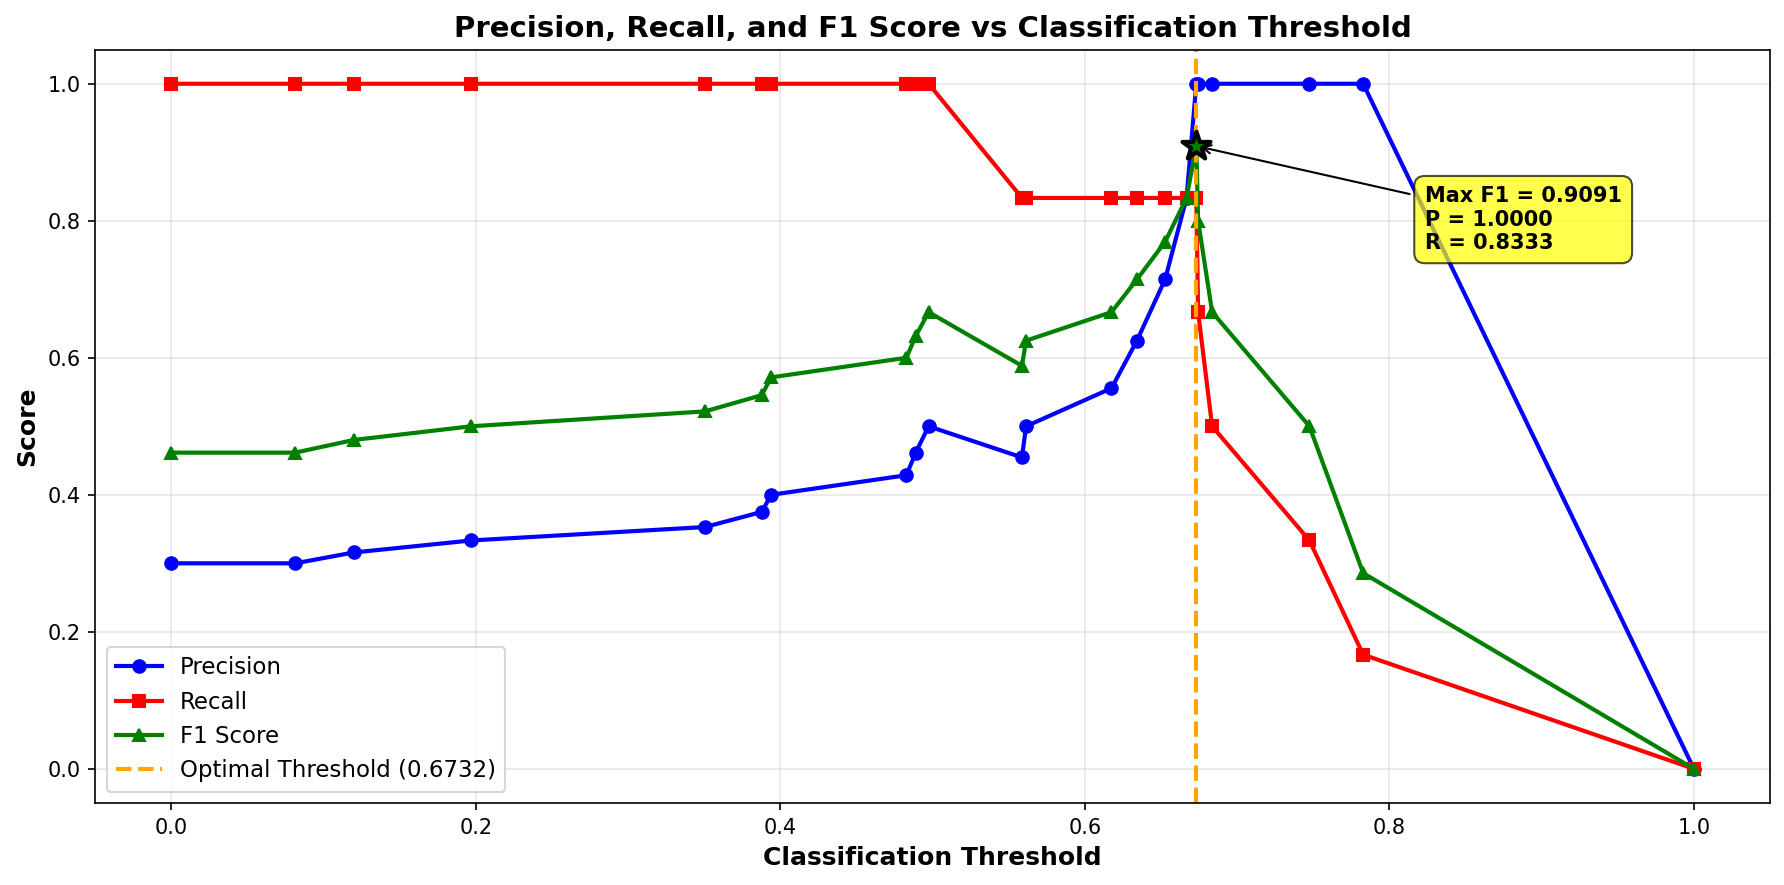

Visualization displayed successfully

FINAL ANSWER

When the F1 Score attains its maximum value of 0.909091:

  ★ PRECISION = 1.000000 (or 100.00%)
  ★ RECALL    = 0.833333 (or 83.33%)

  At Classification Threshold = 0.6732

This means:
  • All 5 predicted events are correct (100% precision)
  • 5 out of 6 actual events are detected (83.33% recall)
  • 1 event is missed (False Negative)
  • 0 false alarms (False Positives)



In [11]:
# Visualize Precision, Recall, and F1 Score across thresholds
import matplotlib.pyplot as plt

print("="*80)
print("THRESHOLD ANALYSIS VISUALIZATION")
print("="*80)

plt.figure(figsize=(12, 6), dpi=150)

# Plot the curves
plt.plot(results_df['Threshold'], results_df['Precision'], 'b-o', label='Precision', linewidth=2, markersize=6)
plt.plot(results_df['Threshold'], results_df['Recall'], 'r-s', label='Recall', linewidth=2, markersize=6)
plt.plot(results_df['Threshold'], results_df['F1_Score'], 'g-^', label='F1 Score', linewidth=2, markersize=6)

# Mark the optimal threshold
optimal_threshold = optimal_result['Threshold']
optimal_f1 = optimal_result['F1_Score']
optimal_precision = optimal_result['Precision']
optimal_recall = optimal_result['Recall']

plt.axvline(x=optimal_threshold, color='orange', linestyle='--', linewidth=2, label=f'Optimal Threshold ({optimal_threshold:.4f})')
plt.scatter([optimal_threshold], [optimal_f1], color='green', s=200, marker='*', zorder=5, edgecolors='black', linewidth=2)

plt.xlabel('Classification Threshold', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Precision, Recall, and F1 Score vs Classification Threshold', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

# Add annotation for optimal point
plt.annotate(f'Max F1 = {optimal_f1:.4f}\nP = {optimal_precision:.4f}\nR = {optimal_recall:.4f}',
            xy=(optimal_threshold, optimal_f1),
            xytext=(optimal_threshold + 0.15, optimal_f1 - 0.15),
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='black'),
            fontsize=10,
            fontweight='bold')

plt.tight_layout()
plt.show()

print("Visualization displayed successfully\n")
print("="*80)
print("FINAL ANSWER")
print("="*80)
print(f"\nWhen the F1 Score attains its maximum value of {optimal_f1:.6f}:")
print(f"\n  ★ PRECISION = {optimal_precision:.6f} (or {optimal_precision*100:.2f}%)")
print(f"  ★ RECALL    = {optimal_recall:.6f} (or {optimal_recall*100:.2f}%)")
print(f"\n  At Classification Threshold = {optimal_threshold:.4f}")
print(f"\nThis means:")
print(f"  • All {int(optimal_result['TP'])} predicted events are correct (100% precision)")
print(f"  • {int(optimal_result['TP'])} out of {int(optimal_result['TP'] + optimal_result['FN'])} actual events are detected ({optimal_recall*100:.2f}% recall)")
print(f"  • {int(optimal_result['FN'])} event is missed (False Negative)")
print(f"  • {int(optimal_result['FP'])} false alarms (False Positives)")
print("\n" + "="*80)

### Un-informative Model RASE (Mean Predictor)

For an un-informative model that always predicts the sample mean $\bar{y}$:

$$
\text{RASE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\bar{y})^2}
$$

Given sample standard deviation $s$ computed with divisor $(n-1)$:

$$
s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(y_i-\bar{y})^2
\Rightarrow
\sum_{i=1}^{n}(y_i-\bar{y})^2 = (n-1)s^2
$$

So,

$$
\text{RASE} = \sqrt{\frac{(n-1)s^2}{n}} = s\sqrt{\frac{n-1}{n}}
$$

With $n=53$ and $s=17.48$:

$$
\text{RASE} = 17.48\sqrt{\frac{52}{53}} \approx 17.3143
$$

In [13]:
# Un-informative model RASE calculation
# Given: n = 53, sample mean = 135.26, sample sd (divisor n-1) = 17.48

n = 53
sample_mean = 135.26
sample_sd = 17.48

# For a model that predicts the sample mean for all observations:
# RASE = sqrt(((n-1)/n) * s^2) = s * sqrt((n-1)/n)
rase_uninformative = sample_sd * numpy.sqrt((n - 1) / n)

print(f"n = {n}")
print(f"Sample mean = {sample_mean:.2f}")
print(f"Sample SD (n-1 divisor) = {sample_sd:.2f}")
print(f"RASE (un-informative mean model) = {rase_uninformative:.4f}")

n = 53
Sample mean = 135.26
Sample SD (n-1 divisor) = 17.48
RASE (un-informative mean model) = 17.3143


### Relative Error for Regression Predictions

Given observed values $y_i$ and predicted values $\hat{y}_i$, the **relative error** (also called normalized squared error) is:

$$
\text{Relative Error} = \frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}
$$

Where:
- Numerator = Sum of Squared Errors (SSE) from the model
- Denominator = Total Sum of Squares (SST) using the mean-only baseline
- Smaller is better; $0$ is perfect, $1$ means same as mean baseline

In [15]:
# Compute relative error from the 10 observed and predicted values
import numpy as np

observed = np.array([6.48, 6.91, 8.31, 4.40, 8.93, 4.99, 8.28, 8.84, 0.95, 5.08])
predicted = np.array([5.96, 9.98, 4.93, 0.98, 5.97, 2.37, 5.44, 6.62, 6.85, 5.74])

y_bar = observed.mean()
sse = np.sum((observed - predicted) ** 2)
sst = np.sum((observed - y_bar) ** 2)
relative_error = sse / sst

print(f"Observed mean (ȳ): {y_bar:.6f}")
print(f"SSE: {sse:.6f}")
print(f"SST: {sst:.6f}")
print(f"Relative Error (SSE/SST): {relative_error:.6f}")
print(f"Relative Error (%): {relative_error*100:.2f}%")

Observed mean (ȳ): 6.317000
SSE: 96.681700
SST: 57.167610
Relative Error (SSE/SST): 1.691197
Relative Error (%): 169.12%


### Decile Targeting Logic (At Least 2x Overall Event Rate)

We should include top deciles (highest predicted probabilities first) while the **cumulative event rate** remains at least twice the overall rate.

1. Compute overall event rate:
   $$
   p_{overall} = \frac{\sum \text{Event}}{\sum (\text{Event} + \text{Non-Event})}
   $$
2. Compute threshold rate:
   $$
   p_{threshold} = 2\times p_{overall}
   $$
3. For cumulative top deciles (0, then 0-1, 0-2, ...), compute:
   $$
   p_{cum}(k)=\frac{\sum_{d=0}^{k}\text{Event}_d}{\sum_{d=0}^{k}(\text{Event}_d+\text{Non-Event}_d)}
   $$
4. Select the **largest** decile cutoff $k$ such that:
   $$
   p_{cum}(k) \ge p_{threshold}
   $$


In [17]:
# Decile targeting computation from provided table
import pandas as pd

decile_df = pd.DataFrame({
    'Decile': list(range(10)),
    'Event': [873, 94, 121, 90, 135, 121, 124, 100, 55, 0],
    'NonEvent': [454, 1234, 1206, 1238, 1192, 1207, 1204, 1227, 1273, 1327]
})

decile_df['Total'] = decile_df['Event'] + decile_df['NonEvent']

overall_event_rate = decile_df['Event'].sum() / decile_df['Total'].sum()
threshold_rate = 2 * overall_event_rate

# cumulative from top scores (decile 0 downward)
decile_df['CumEvent'] = decile_df['Event'].cumsum()
decile_df['CumTotal'] = decile_df['Total'].cumsum()
decile_df['CumEventRate'] = decile_df['CumEvent'] / decile_df['CumTotal']
decile_df['ReachPct'] = decile_df['CumTotal'] / decile_df['Total'].sum()
decile_df['Eligible'] = decile_df['CumEventRate'] >= threshold_rate

eligible_rows = decile_df[decile_df['Eligible']]
max_row = eligible_rows.iloc[-1]

print('Overall Event Rate: {:.4%}'.format(overall_event_rate))
print('2x Threshold Rate:  {:.4%}'.format(threshold_rate))
print('\nCumulative performance by decile cutoff (top-down):')
print(decile_df[['Decile', 'CumEvent', 'CumTotal', 'CumEventRate', 'ReachPct', 'Eligible']].to_string(index=False))

print('\nFinal Decision:')
print(f"Reach deciles 0 through {int(max_row['Decile'])}")
print('Maximum reach: {:.1%}'.format(max_row['ReachPct']))
print('Cumulative event rate at this cutoff: {:.4%}'.format(max_row['CumEventRate']))

Overall Event Rate: 12.9040%
2x Threshold Rate:  25.8079%

Cumulative performance by decile cutoff (top-down):
 Decile  CumEvent  CumTotal  CumEventRate     ReachPct  Eligible
      0       873      1327  0.6578749058 0.0999623352      True
      1       967      2655  0.3642184557 0.2000000000      True
      2      1088      3982  0.2732295329 0.2999623352      True
      3      1178      5310  0.2218455744 0.4000000000     False
      4      1313      6637  0.1978303450 0.4999623352     False
      5      1434      7965  0.1800376648 0.6000000000     False
      6      1558      9293  0.1676530722 0.7000376648     False
      7      1658     10620  0.1561205273 0.8000000000     False
      8      1713     11948  0.1433712755 0.9000376648     False
      9      1713     13275  0.1290395480 1.0000000000     False

Final Decision:
Reach deciles 0 through 2
Maximum reach: 30.0%
Cumulative event rate at this cutoff: 27.3230%
